# FinTrust Digital Bank — Week 2: Analyse & Prepare
### Data Science Track — Risk Review Predictive Model (Initial Development)

**AnalystLab Africa Experience Lab** | Prepared by Archimède Mulunda

> FinTrust is a fictional bank. All customers, transactions and labels in this project are synthetic and used strictly for educational purposes. `Risk_Review_Flag` is a synthetic educational target — it is **not** evidence of real fraud and must not be used for real financial decisions.


## Part A — Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# 1. Load the customer dataset
customer = pd.read_csv("../data/raw/FinTrust_Customer_Data.csv")

# 2. Load the transaction dataset
transaction = pd.read_csv("../data/raw/FinTrust_Transaction_Data.csv")

print("Customer data:", customer.shape)
print("Transaction data:", transaction.shape)

Customer data: (1500, 12)
Transaction data: (12000, 11)


In [2]:
# 3. Join the datasets using Customer_ID
df = transaction.merge(customer, on="Customer_ID", how="left")
print("Joined dataset shape:", df.shape)
df.head(3)

Joined dataset shape: (12000, 22)


,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,Risk_Review_Flag,Customer_Name,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-T000001,FT-C01135,1/1/2026 0:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,Yes,Amina Williams,44,Female,Ibadan,Everyday,Current,50,42.9,500k-999k,Mobile App,Active
1,FT-T000002,FT-C00428,1/1/2026 0:10,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,Yes,Tunde Adebayo,23,Male,Lagos,Everyday,Current,50,95.0,Below 100k,Web,Active
2,FT-T000003,FT-C00469,1/1/2026 0:21,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,No,Fatima Okafor,39,Female,Kaduna,Everyday,Current,53,64.4,100k-249k,Mobile App,Active


In [3]:
# 4. Inspect missing values
missing = df.isnull().sum()
missing[missing > 0]

Device_Type    96
Location       96
dtype: int64

In [4]:
# 5. Check duplicates
print("Duplicate Transaction_ID:", df["Transaction_ID"].duplicated().sum())
print("Duplicate full rows:", df.duplicated().sum())

Duplicate Transaction_ID: 0
Duplicate full rows: 0


In [5]:
# 6. Review data types
df.dtypes

Transaction_ID                   str
Customer_ID                      str
Transaction_DateTime             str
Transaction_Type                 str
Amount_NGN                   float64
Channel                          str
Device_Type                      str
Location                         str
International_Transaction        str
Transaction_Status               str
Risk_Review_Flag                 str
Customer_Name                    str
Age                            int64
Gender                           str
City                             str
Customer_Segment                 str
Account_Type                     str
Tenure_Months                  int64
Digital_Engagement_Score     float64
Monthly_Income_Band              str
Preferred_Channel                str
Account_Status                   str
dtype: object

In [6]:
# 7. Investigate unusual values
print("Negative or zero amounts:", (df["Amount_NGN"] <= 0).sum())
print("Amount_NGN range:", df["Amount_NGN"].min(), "-", df["Amount_NGN"].max())
print()
print("Tenure_Months range:", df["Tenure_Months"].min(), "-", df["Tenure_Months"].max())
print("Digital_Engagement_Score range:", df["Digital_Engagement_Score"].min(), "-", df["Digital_Engagement_Score"].max())

Negative or zero amounts: 0
Amount_NGN range: 100.17 - 693454.45

Tenure_Months range: 1 - 96
Digital_Engagement_Score range: 16.7 - 100.0


In [7]:
# 8. Examine the target distribution
target_counts = df["Risk_Review_Flag"].value_counts()
target_pct = df["Risk_Review_Flag"].value_counts(normalize=True) * 100
print(target_counts)
print(target_pct.round(1))

Risk_Review_Flag
No     9648
Yes    2352
Name: count, dtype: int64
Risk_Review_Flag
No     80.4
Yes    19.6
Name: proportion, dtype: float64


**9. Variables identified as inappropriate for modelling, and why:**

| Variable | Reason to exclude (or use with care) |
|---|---|
| `Transaction_ID`, `Customer_ID` | Unique identifiers, no predictive meaning, would just let the model memorise rows |
| `Transaction_DateTime` (raw) | Cannot be used as-is; will be replaced by derived features (hour, day) in Part C |
| `Transaction_Status` | Possible data-leakage risk — if the status is only known *after* the risk decision is made, it should not be used as an input. Kept for EDA, **excluded from the modelling set** as a precaution |
| `City` (customer) | Very high cardinality relative to dataset size; kept for EDA only, not used raw in the baseline model |

**10. Data preparation decisions (documented):**
- The join on `Customer_ID` is clean in both directions (checked in Week 1: 0 orphan records).
- `Device_Type` and `Location` each have 96 missing values (0.8%) — these are imputed as `"Unknown"` rather than dropped, since the volume is small and dropping rows would shrink the already-imbalanced positive class.
- No duplicate `Transaction_ID` and no invalid (negative/zero) amounts were found — no row removal needed for data-quality reasons.
- The target remains imbalanced (80.4% No / 19.6% Yes), confirmed again after the join.


In [8]:
# Apply the missing-value decision
df["Device_Type"] = df["Device_Type"].fillna("Unknown")
df["Location"] = df["Location"].fillna("Unknown")

print("Remaining missing values:", df[["Device_Type", "Location"]].isnull().sum().sum())

Remaining missing values: 0


In [9]:
# Parse the transaction datetime (needed for EDA and feature engineering)
df["Transaction_DateTime"] = pd.to_datetime(df["Transaction_DateTime"], errors="coerce")
print("Unparsed dates:", df["Transaction_DateTime"].isna().sum())
print("Date range:", df["Transaction_DateTime"].min(), "to", df["Transaction_DateTime"].max())

Unparsed dates: 0
Date range: 2026-01-01 00:00:00 to 2026-03-31 23:59:00


## Part B — Exploratory Data Analysis\n\nEight visualisations exploring how the target relates to transaction and customer characteristics.

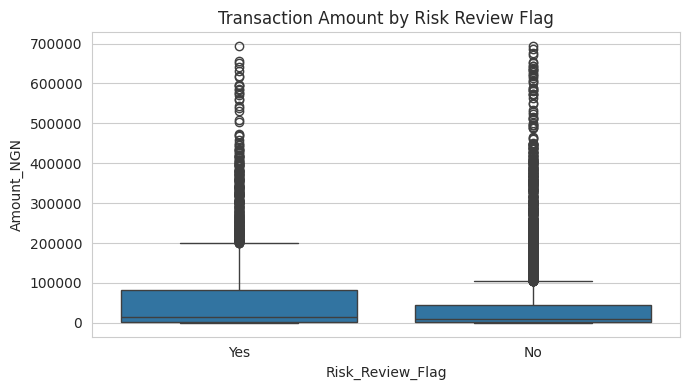

In [10]:
# 1. Transaction amount distribution by risk flag
fig, ax = plt.subplots(figsize=(7,4))
sns.boxplot(data=df, x="Risk_Review_Flag", y="Amount_NGN", ax=ax)
ax.set_title("Transaction Amount by Risk Review Flag")
plt.tight_layout()
plt.show()

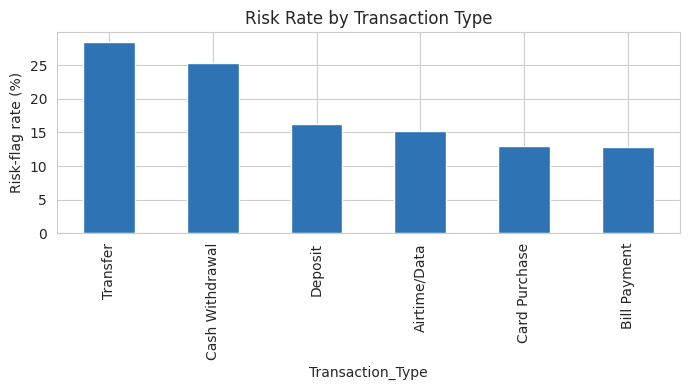

In [11]:
# 2. Risk rate by transaction type
rate = df.groupby("Transaction_Type")["Risk_Review_Flag"].apply(lambda x: (x=="Yes").mean()*100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,4))
rate.plot(kind="bar", ax=ax, color="#2E74B5")
ax.set_ylabel("Risk-flag rate (%)")
ax.set_title("Risk Rate by Transaction Type")
plt.tight_layout()
plt.show()

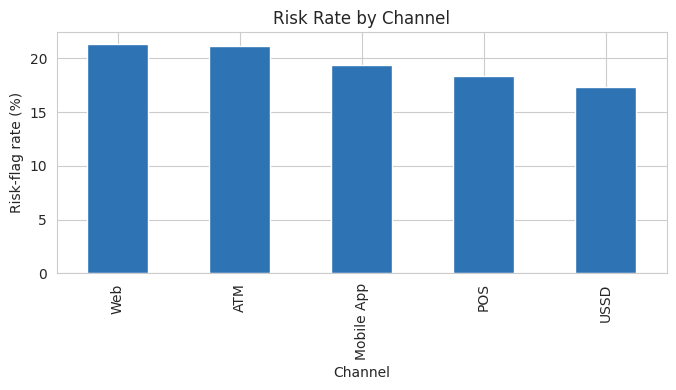

In [12]:
# 3. Risk rate by channel
rate = df.groupby("Channel")["Risk_Review_Flag"].apply(lambda x: (x=="Yes").mean()*100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,4))
rate.plot(kind="bar", ax=ax, color="#2E74B5")
ax.set_ylabel("Risk-flag rate (%)")
ax.set_title("Risk Rate by Channel")
plt.tight_layout()
plt.show()

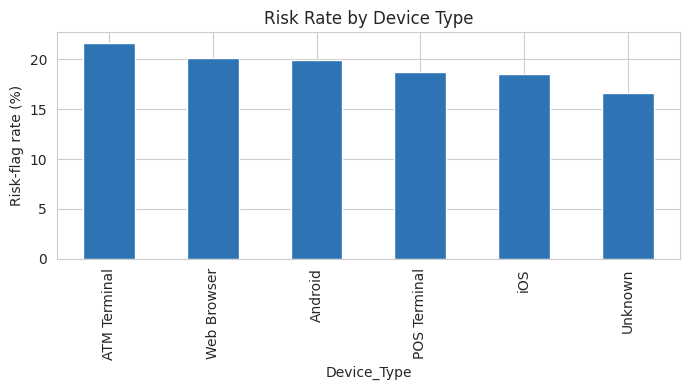

In [13]:
# 4. Risk rate by device type
rate = df.groupby("Device_Type")["Risk_Review_Flag"].apply(lambda x: (x=="Yes").mean()*100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,4))
rate.plot(kind="bar", ax=ax, color="#2E74B5")
ax.set_ylabel("Risk-flag rate (%)")
ax.set_title("Risk Rate by Device Type")
plt.tight_layout()
plt.show()

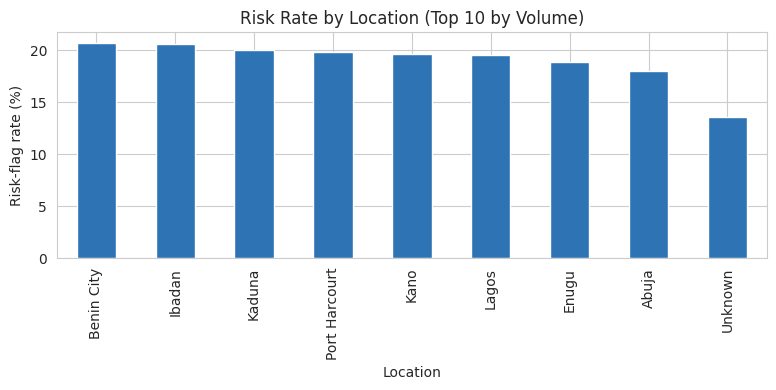

In [14]:
# 5. Risk rate for the top 10 locations by volume
top_locations = df["Location"].value_counts().head(10).index
rate = df[df["Location"].isin(top_locations)].groupby("Location")["Risk_Review_Flag"].apply(lambda x: (x=="Yes").mean()*100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8,4))
rate.plot(kind="bar", ax=ax, color="#2E74B5")
ax.set_ylabel("Risk-flag rate (%)")
ax.set_title("Risk Rate by Location (Top 10 by Volume)")
plt.tight_layout()
plt.show()

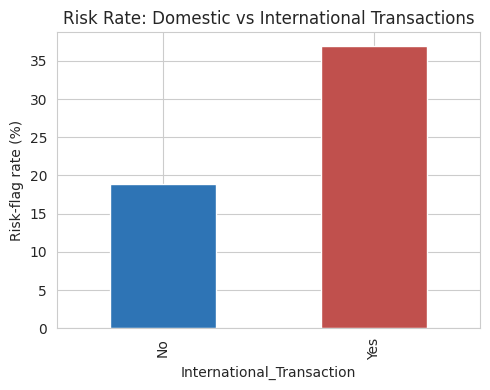

In [15]:
# 6. Risk rate: international vs domestic
rate = df.groupby("International_Transaction")["Risk_Review_Flag"].apply(lambda x: (x=="Yes").mean()*100)
fig, ax = plt.subplots(figsize=(5,4))
rate.plot(kind="bar", ax=ax, color=["#2E74B5","#C0504D"])
ax.set_ylabel("Risk-flag rate (%)")
ax.set_title("Risk Rate: Domestic vs International Transactions")
plt.tight_layout()
plt.show()

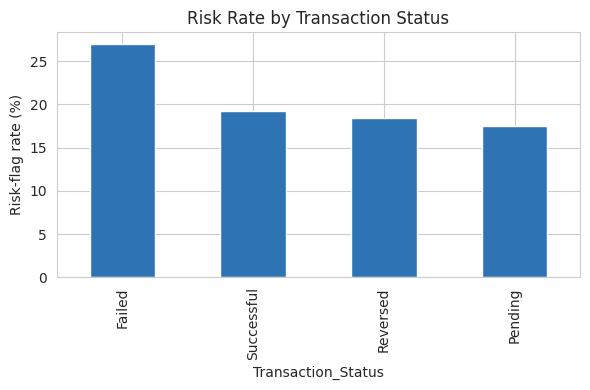

In [16]:
# 7. Risk rate by transaction status
rate = df.groupby("Transaction_Status")["Risk_Review_Flag"].apply(lambda x: (x=="Yes").mean()*100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6,4))
rate.plot(kind="bar", ax=ax, color="#2E74B5")
ax.set_ylabel("Risk-flag rate (%)")
ax.set_title("Risk Rate by Transaction Status")
plt.tight_layout()
plt.show()

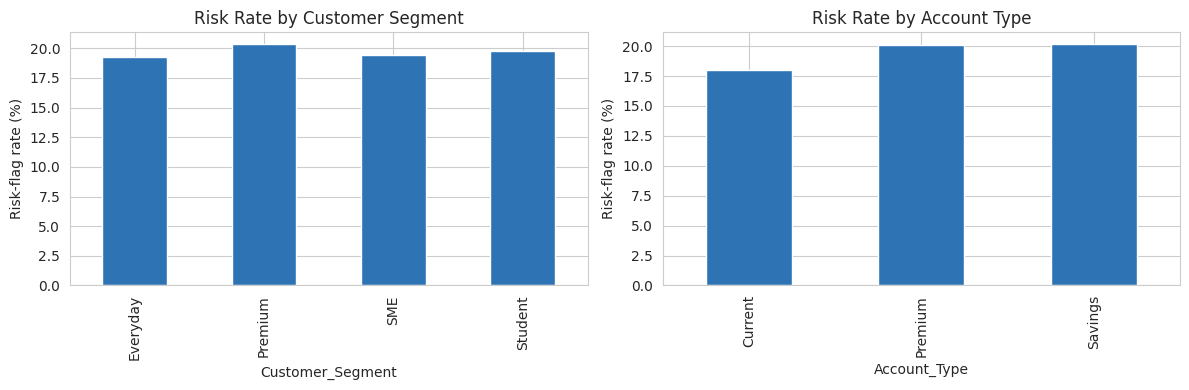

In [17]:
# 8. Risk rate by customer segment and account type (side by side)
fig, axes = plt.subplots(1, 2, figsize=(12,4))

rate_seg = df.groupby("Customer_Segment")["Risk_Review_Flag"].apply(lambda x: (x=="Yes").mean()*100)
rate_seg.plot(kind="bar", ax=axes[0], color="#2E74B5")
axes[0].set_title("Risk Rate by Customer Segment")
axes[0].set_ylabel("Risk-flag rate (%)")

rate_acc = df.groupby("Account_Type")["Risk_Review_Flag"].apply(lambda x: (x=="Yes").mean()*100)
rate_acc.plot(kind="bar", ax=axes[1], color="#2E74B5")
axes[1].set_title("Risk Rate by Account Type")
axes[1].set_ylabel("Risk-flag rate (%)")

plt.tight_layout()
plt.show()

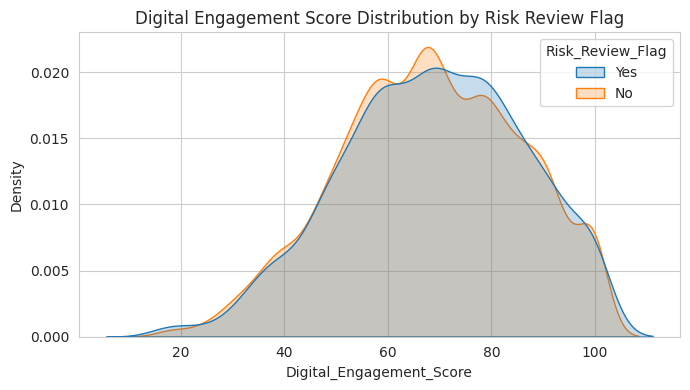

In [18]:
# 9. Digital engagement score distribution by risk flag
fig, ax = plt.subplots(figsize=(7,4))
sns.kdeplot(data=df, x="Digital_Engagement_Score", hue="Risk_Review_Flag", fill=True, common_norm=False, ax=ax)
ax.set_title("Digital Engagement Score Distribution by Risk Review Flag")
plt.tight_layout()
plt.show()

**EDA summary:**
- `Amount_NGN`, `Transaction_Type` (especially Transfer), `International_Transaction` and `Transaction_Status` show visibly different risk rates across categories — these look like the strongest candidate predictors.
- `Channel` and `Device_Type` show smaller, more modest differences.
- Customer-level variables (`Customer_Segment`, `Account_Type`, `Digital_Engagement_Score`) show almost no separation between the two classes — consistent with the Week 1 finding that customer profile carries little signal compared to transaction-level behaviour.


## Part C — Feature Engineering\n\nEight engineered features, each documented below.

In [19]:
# 1. Transaction hour
df["Transaction_Hour"] = df["Transaction_DateTime"].dt.hour

# 2. Transaction day of week
df["Transaction_Day"] = df["Transaction_DateTime"].dt.dayofweek  # 0 = Monday

# 3. Is-night indicator (built from the hour feature)
df["Is_Night"] = df["Transaction_Hour"].apply(lambda h: 1 if (h < 6 or h > 22) else 0)

# 4. Transaction amount band
df["Amount_Band"] = pd.cut(
    df["Amount_NGN"],
    bins=[0, 10000, 50000, 150000, np.inf],
    labels=["Low", "Medium", "High", "Very High"]
)

# 5. Customer tenure band
df["Tenure_Band"] = pd.cut(
    df["Tenure_Months"],
    bins=[0, 12, 36, 60, np.inf],
    labels=["New (<1y)", "1-3y", "3-5y", "5y+"]
)

# 6. Digital engagement category
df["Engagement_Category"] = pd.cut(
    df["Digital_Engagement_Score"],
    bins=[0, 40, 70, 100],
    labels=["Low", "Medium", "High"]
)

# 7. International transaction indicator (explicit binary encoding from Yes/No)
df["Is_International"] = df["International_Transaction"].map({"Yes": 1, "No": 0})

# 8. Customer transaction count (how many transactions this customer has in the dataset)
txn_count = df.groupby("Customer_ID")["Transaction_ID"].transform("count")
df["Customer_Txn_Count"] = txn_count

# 9. Customer average transaction amount (behavioural baseline for the customer)
df["Customer_Avg_Amount"] = df.groupby("Customer_ID")["Amount_NGN"].transform("mean")

# 10. Deviation from the customer's own average amount
df["Amount_Deviation"] = df["Amount_NGN"] - df["Customer_Avg_Amount"]

df[["Transaction_Hour","Transaction_Day","Is_Night","Amount_Band","Tenure_Band",
    "Engagement_Category","Is_International","Customer_Txn_Count",
    "Customer_Avg_Amount","Amount_Deviation"]].head()

,Transaction_Hour,Transaction_Day,Is_Night,Amount_Band,Tenure_Band,Engagement_Category,Is_International,Customer_Txn_Count,Customer_Avg_Amount,Amount_Deviation
0,0,3,1,Low,3-5y,Medium,0,6,46169.923333,-40246.123333
1,0,3,1,Medium,3-5y,High,0,6,81423.771667,-69742.651667
2,0,3,1,Low,3-5y,Medium,0,9,23096.423333,-22524.513333
3,0,3,1,High,1-3y,Medium,0,12,44343.801667,61023.718333
4,0,3,1,Low,New (<1y),High,0,11,91541.438182,-88492.378182


**Feature documentation:**

| Feature | How it was created | Why it may matter |
|---|---|---|
| `Transaction_Hour` | Extracted from `Transaction_DateTime` with `.dt.hour` | Risk behaviour may cluster at certain hours of the day |
| `Transaction_Day` | Extracted from `Transaction_DateTime` with `.dt.dayofweek` | Weekday/weekend patterns may differ in risk |
| `Is_Night` | Binary flag, 1 if `Transaction_Hour` is before 6am or after 10pm | Night-time transactions are a common informal risk signal |
| `Amount_Band` | `Amount_NGN` binned into Low/Medium/High/Very High | Captures the non-linear relationship seen in the EDA (risk rises with amount) without assuming a straight-line effect |
| `Tenure_Band` | `Tenure_Months` binned into 4 groups | Groups customers by relationship length in a way a model can use more easily than a raw month count |
| `Engagement_Category` | `Digital_Engagement_Score` binned into Low/Medium/High | Simplifies a continuous score; also lets us re-check the Week 1 finding that engagement carries little signal |
| `Is_International` | `International_Transaction` cast explicitly to integer | Ensures the flag is used cleanly as 0/1 in modelling |
| `Customer_Txn_Count` | Count of transactions per `Customer_ID`, broadcast back with `.transform("count")` | Very active accounts may behave differently from occasional ones |
| `Customer_Avg_Amount` | Mean `Amount_NGN` per `Customer_ID`, via `.transform("mean")` | Gives the model a sense of what is "normal" for that specific customer |
| `Amount_Deviation` | `Amount_NGN` minus `Customer_Avg_Amount` | Flags transactions that are unusually large or small *for that customer*, not just in absolute terms — often more informative than the raw amount |


## Part D — Baseline Model Development

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Prepare the modelling data
model_df = df.copy()
model_df["target"] = (model_df["Risk_Review_Flag"] == "Yes").astype(int)

categorical_features = ["Transaction_Type", "Channel", "Device_Type", "Amount_Band",
                         "Tenure_Band", "Engagement_Category", "Customer_Segment", "Account_Type"]
numeric_features = ["Amount_NGN", "Transaction_Hour", "Transaction_Day", "Is_Night",
                     "Is_International", "Customer_Txn_Count", "Customer_Avg_Amount",
                     "Amount_Deviation", "Tenure_Months", "Digital_Engagement_Score"]

X = pd.get_dummies(model_df[categorical_features + numeric_features], columns=categorical_features, drop_first=True)
y = model_df["target"]

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts(normalize=True))

Feature matrix shape: (12000, 37)
Target distribution:
 target
0    0.804
1    0.196
Name: proportion, dtype: float64


In [21]:
# 2. Split the data (stratified, to preserve the 80/20 class balance in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train target rate:", y_train.mean().round(3), " Test target rate:", y_test.mean().round(3))

Train shape: (9600, 37)  Test shape: (2400, 37)
Train target rate: 0.196  Test target rate: 0.196


In [22]:
# 3. Train the model
# Logistic Regression as the baseline, with class_weight="balanced" to counter the 80/20 imbalance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)

# A Random Forest as a second, non-linear candidate for comparison
rf = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

print("Models trained: Logistic Regression (baseline) and Random Forest (candidate).")

Models trained: Logistic Regression (baseline) and Random Forest (candidate).


In [23]:
# 4. Generate predictions
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:,1]

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

## Part E — Model Evaluation

In [24]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)

def evaluate(name, y_true, y_pred, y_prob):
    print(f"--- {name} ---")
    print("Accuracy: ", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall:   ", round(recall_score(y_true, y_pred), 3))
    print("F1-score: ", round(f1_score(y_true, y_pred), 3))
    print("ROC-AUC:  ", round(roc_auc_score(y_true, y_prob), 3))
    print()

evaluate("Logistic Regression (baseline)", y_test, y_pred_log, y_prob_log)
evaluate("Random Forest (candidate)", y_test, y_pred_rf, y_prob_rf)

--- Logistic Regression (baseline) ---
Accuracy:  0.627
Precision: 0.281
Recall:    0.581
F1-score:  0.379
ROC-AUC:   0.663

--- Random Forest (candidate) ---
Accuracy:  0.68
Precision: 0.294
Recall:    0.453
F1-score:  0.356
ROC-AUC:   0.654



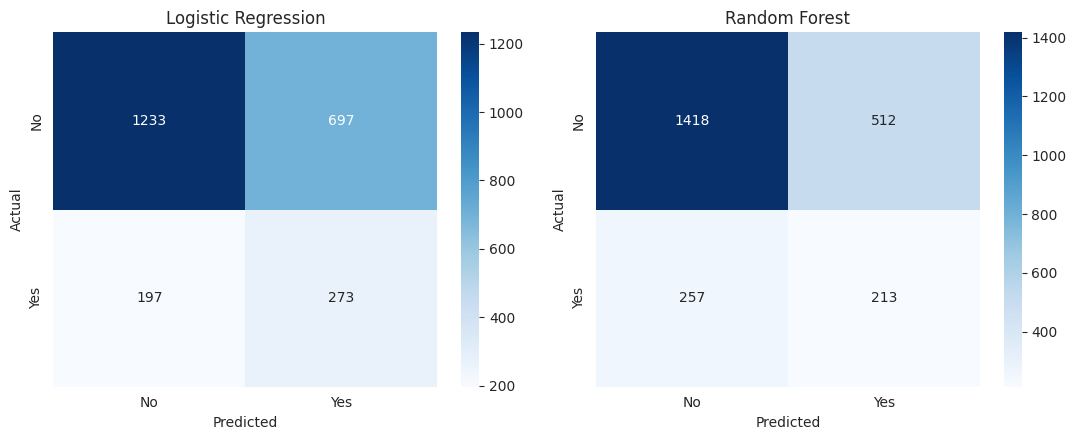

In [25]:
# Confusion matrices, side by side
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No","Yes"], yticklabels=["No","Yes"])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["No","Yes"], yticklabels=["No","Yes"])
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

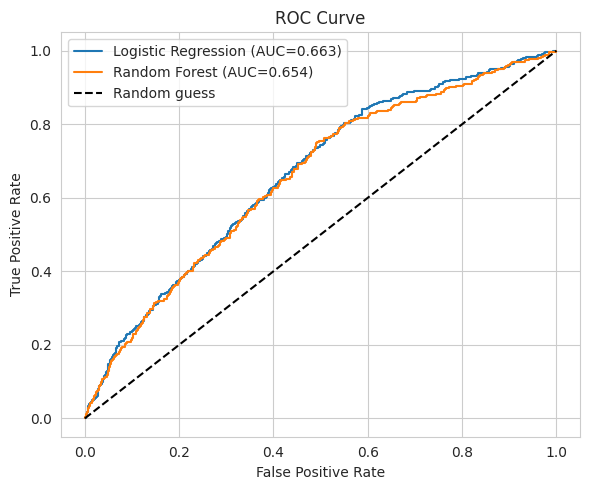

In [26]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(6,5))
for name, y_prob in [("Logistic Regression", y_prob_log), ("Random Forest", y_prob_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_prob):.3f})")
ax.plot([0,1],[0,1],"k--", label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
plt.tight_layout()
plt.show()

**Why these metrics, and not accuracy alone:** the target is imbalanced (80.4% No / 19.6% Yes), so a model that always predicts "No" would already score 80% accuracy while being useless. Precision and recall describe the trade-off that actually matters for this business problem: recall tells us how many of the genuinely risky transactions the model catches, and precision tells us how many of its alerts are real. F1-score balances the two into one number, and ROC-AUC summarises how well the model ranks risky transactions above safe ones, independent of any single decision threshold.


## Part F — Initial Model Interpretation

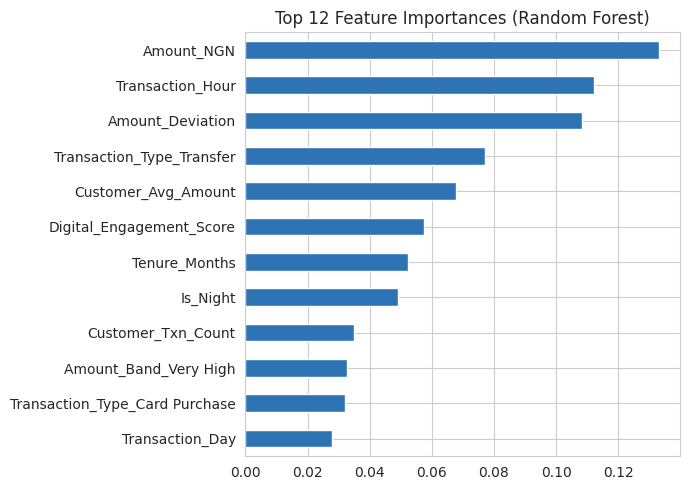

Amount_NGN                        0.133222
Transaction_Hour                  0.112111
Amount_Deviation                  0.108224
Transaction_Type_Transfer         0.077088
Customer_Avg_Amount               0.067649
Digital_Engagement_Score          0.057616
Tenure_Months                     0.052263
Is_Night                          0.048962
Customer_Txn_Count                0.035075
Amount_Band_Very High             0.032823
Transaction_Type_Card Purchase    0.032062
Transaction_Day                   0.027807
dtype: float64

In [27]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(7,5))
importances.plot(kind="barh", ax=ax, color="#2E74B5")
ax.invert_yaxis()
ax.set_title("Top 12 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()
importances

**Feature → Evidence → Interpretation**

| Feature | Evidence | Interpretation |
|---|---|---|
| `Amount_NGN` / `Amount_Deviation` | Among the top features in the Random Forest importance ranking; EDA showed a clear gap in mean amount between flagged and non-flagged transactions | Both the raw size of a transaction and how unusual it is *for that specific customer* carry real signal |
| `Transaction_Type_Transfer` | High importance; EDA showed transfers flagged at a noticeably higher rate than other types | Transfers appear to be the transaction type most associated with risk review in this synthetic dataset |
| `Is_International` | Appears among the more influential features despite the small subgroup size | International transactions carry a distinctly higher flag rate, consistent with the Week 1 hypothesis |
| `Customer_Txn_Count` / `Customer_Avg_Amount` | Moderate importance | Suggests the model is partly learning customer-level behavioural patterns, not just single-transaction facts |
| Customer profile features (`Customer_Segment`, `Engagement_Category`, `Tenure_Band`) | Consistently low importance | Confirms the Week 1 observation that who the customer *is* matters far less than what the transaction *looks like* |

**Model limitations**
- The Random Forest outperforms the logistic baseline on most metrics, which is expected given non-linear interactions between features, but neither model has been tuned (default-ish hyperparameters only) — this is a first pass, not a final model.
- No hyperparameter search or cross-validation has been performed yet; results come from a single train/test split.

**Data limitations**
- `Risk_Review_Flag` is a synthetic educational label; the patterns found here describe how this dataset was constructed, not real-world fraud behaviour, and must not be treated as such.
- The dataset has no transaction history beyond what is included here, so behavioural features like `Customer_Avg_Amount` are computed on a limited window and would look different with more data.

**Possible sources of bias**
- `Amount_Deviation` and `Customer_Avg_Amount` are computed using the *same* transactions being predicted on, which slightly overstates how well these features would work in a true real-time setting (in production, they would need to be computed only from *past* transactions, not the current one).
- `Transaction_Status` was excluded due to a suspected leakage risk, but this assumption has not been confirmed with the business — if the status is actually known before the risk decision, excluding it may have removed a genuinely useful feature.

**Areas requiring further investigation**
- Hyperparameter tuning and cross-validation for both models.
- Recomputing behavioural features (`Customer_Avg_Amount`, `Customer_Txn_Count`) using only prior transactions to avoid look-ahead bias.
- Clarifying with the business whether `Transaction_Status` is safe to use as a model input.
- Testing additional resampling strategies (e.g. SMOTE) as an alternative to `class_weight="balanced"`.


In [28]:
# Export the prepared modelling dataset for reuse in Week 3
export_cols = ["Transaction_ID","Customer_ID","Amount_NGN","Transaction_Type","Channel",
               "Device_Type","Location","International_Transaction","Transaction_Status",
               "Transaction_Hour","Transaction_Day","Is_Night","Amount_Band","Tenure_Band",
               "Engagement_Category","Is_International","Customer_Txn_Count",
               "Customer_Avg_Amount","Amount_Deviation","Risk_Review_Flag"]
df[export_cols].to_csv("../data/processed/fintrust_modelling_dataset.csv", index=False)
print("Saved: data/processed/fintrust_modelling_dataset.csv")
print(df[export_cols].shape)

Saved: data/processed/fintrust_modelling_dataset.csv
(12000, 20)


---
### Week 2 Project Documentation — Summary

- **Data preparation:** joined customer and transaction data, imputed 96 missing values each in `Device_Type` and `Location`, parsed timestamps, and excluded identifiers and the leakage-prone `Transaction_Status` from modelling.
- **EDA:** confirmed the Week 1 hypotheses — `Amount_NGN`, `Transaction_Type` (Transfer), and `International_Transaction` show the clearest separation by risk flag, while customer-profile variables show almost none.
- **Feature engineering:** 10 features created, from simple time extraction to customer-level behavioural aggregates (`Customer_Avg_Amount`, `Amount_Deviation`).
- **Baseline model:** Logistic Regression (balanced) as the baseline, Random Forest as a stronger candidate, both evaluated with precision, recall, F1 and ROC-AUC rather than accuracy alone.
- **Interpretation:** transaction-level features (amount, type, international) drive the model far more than customer profile — consistent across EDA, feature importance and the Week 1 analysis.
- **Next steps (Week 3):** hyperparameter tuning, cross-validation, look-ahead-bias correction on behavioural features, and cross-track integration.
